In [6]:
from datasets import load_dataset, concatenate_datasets, Dataset
from pathlib import Path
import random

DATASETS_CONFIG = [
    {
        "hf_name": "katarinagresova/Genomic_Benchmarks_human_enhancers_ensembl",
        "label": "ENHANCER",
    },
    {
        "hf_name": "katarinagresova/Genomic_Benchmarks_human_nontata_promoters",
        "label": "PROMOTER",
    },
    {
        "hf_name": "katarinagresova/Genomic_Benchmarks_demo_coding_vs_intergenomic_seqs",
        "label": "INTERGENIC",
        "filter_label": 0  # Filter for intergenic sequences only
    }
]

LABEL2ID = {
    "ENHANCER": 0,
    "PROMOTER": 1,
    "INTERGENIC": 2
}

MIN_SEQ_LENGTH = 2
MAX_SEQ_LENGTH = 512

def find_sequence_column(column_names):
    for candidate in ["sequence", "seq", "dna"]:
        if candidate in column_names:
            return candidate
    raise ValueError(f"No sequence column found in {column_names}")

def resize_intergenic_sequences(dataset, label_str):
    """Cut and concatenate intergenic sequences to fit 2-512 range."""
    if label_str != "INTERGENIC":
        return dataset
    
    resized_samples = []
    sequences = [item["sequence"] for item in dataset]
    metadata = [
        {k: v for k, v in item.items() if k != "sequence"} 
        for item in dataset
    ]
    
    buffer = ""
    buffer_metadata = None
    
    for seq, meta in zip(sequences, metadata):
        buffer += seq
        if buffer_metadata is None:
            buffer_metadata = meta
        
        # Extract sequences of target length from buffer
        while len(buffer) >= MIN_SEQ_LENGTH:
            if len(buffer) <= MAX_SEQ_LENGTH:
                # Use entire buffer
                resized_samples.append({
                    "sequence": buffer,
                    **buffer_metadata
                })
                buffer = ""
                buffer_metadata = None
                break
            else:
                # Extract a chunk between MIN and MAX length
                chunk_size = random.randint(MIN_SEQ_LENGTH, MAX_SEQ_LENGTH)
                resized_samples.append({
                    "sequence": buffer[:chunk_size],
                    **buffer_metadata
                })
                buffer = buffer[chunk_size:]
    
    # Handle remaining buffer if it meets minimum length
    if len(buffer) >= MIN_SEQ_LENGTH:
        resized_samples.append({
            "sequence": buffer,
            **buffer_metadata
        })
    
    return Dataset.from_list(resized_samples)

def load_and_label_dataset(hf_name, label_str, filter_label=None):
    ds = load_dataset(hf_name)
    
    if isinstance(ds, dict):
        ds = concatenate_datasets(list(ds.values()))
    
    # Filter for specific label if specified (e.g., intergenic only)
    if filter_label is not None:
        ds = ds.filter(lambda x: x.get("label") == filter_label)

    seq_col = find_sequence_column(ds.column_names)
    label_id = LABEL2ID[label_str]

    ds = ds.map(
        lambda x: {
            "sequence": x[seq_col],
            "label": label_id,
            "label_name": label_str,
            "source_dataset": hf_name,
        },
        remove_columns=ds.column_names,
    )
    
    # Resize intergenic sequences
    ds = resize_intergenic_sequences(ds, label_str)

    return ds

all_datasets = []

for cfg in DATASETS_CONFIG:
    print(f"Loading {cfg['hf_name']} ...")
    ds = load_and_label_dataset(
        cfg["hf_name"], 
        cfg["label"],
        filter_label=cfg.get("filter_label")
    )
    print(f"  Loaded {len(ds)} samples for {cfg['label']}")
    all_datasets.append(ds)

unified_dataset = concatenate_datasets(all_datasets)

print("\nUnified dataset created:")
print(unified_dataset)

# Print sequence length statistics
import pandas as pd
lengths = [len(item["sequence"]) for item in unified_dataset]
print(f"\nSequence length statistics:")
print(f"  Min: {min(lengths)}")
print(f"  Max: {max(lengths)}")
print(f"  Mean: {sum(lengths)/len(lengths):.1f}")

output_dir = Path("/tf/unified_DNA_dataset")
output_dir.mkdir(exist_ok=True)

parquet_path = output_dir / "DNA_multiclass.parquet"
unified_dataset.to_parquet(parquet_path)

print(f"\nDataset saved to: {parquet_path.resolve()}")

Loading katarinagresova/Genomic_Benchmarks_human_enhancers_ensembl ...
  Loaded 154842 samples for ENHANCER
Loading katarinagresova/Genomic_Benchmarks_human_nontata_promoters ...
  Loaded 36131 samples for PROMOTER
Loading katarinagresova/Genomic_Benchmarks_demo_coding_vs_intergenomic_seqs ...
  Loaded 50000 samples for INTERGENIC

Unified dataset created:
Dataset({
    features: ['label', 'sequence', 'label_name', 'source_dataset'],
    num_rows: 240973
})

Sequence length statistics:
  Min: 2
  Max: 573
  Mean: 251.9


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]


Dataset saved to: /tf/unified_DNA_dataset/DNA_multiclass.parquet


In [7]:
import pandas as pd

df = pd.read_parquet("/tf/unified_DNA_dataset/DNA_multiclass.parquet")

print("Sequence length statistics:")
print(df["sequence"].str.len().describe())

print("\nOriginal label distribution:")
print(df["label"].value_counts())

min_count = df["label"].value_counts().min()
print(f"\nDownsampling all classes to {min_count} samples")

# Sample from each group separately then concatenate
sampled_groups = []
for label in df["label"].unique():
    group = df[df["label"] == label]
    sampled = group.sample(n=min_count, random_state=42)
    sampled_groups.append(sampled)

df_balanced = pd.concat(sampled_groups, ignore_index=True)
df_balanced = df_balanced.sample(
    frac=1, random_state=42).reset_index(drop=True)  # shuffle

print("\nBalanced label distribution:")
print(df_balanced["label"].value_counts())

print("\nBalanced sequence length statistics:")
print(df_balanced["sequence"].str.len().describe())

output_path = "./unified_DNA_dataset/DNA_multiclass_balanced.parquet"
df_balanced.to_parquet(output_path, index=False)

print(f"\nBalanced dataset saved to: {output_path}")


Sequence length statistics:
count    240973.000000
mean        251.896856
std         102.030294
min           2.000000
25%         200.000000
50%         251.000000
75%         310.000000
max         573.000000
Name: sequence, dtype: float64

Original label distribution:
label
0    154842
2     50000
1     36131
Name: count, dtype: int64

Downsampling all classes to 36131 samples

Balanced label distribution:
label
2    36131
0    36131
1    36131
Name: count, dtype: int64

Balanced sequence length statistics:
count    108393.000000
mean        240.174347
std          76.506060
min           2.000000
25%         200.000000
50%         251.000000
75%         251.000000
max         573.000000
Name: sequence, dtype: float64

Balanced dataset saved to: ./unified_DNA_dataset/DNA_multiclass_balanced.parquet


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from collections import Counter

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer

LABEL2ID = {"ENHANCER": 0, "PROMOTER": 1, "INTERGENIC": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LABEL_MAP = ["ENHANCER", "PROMOTER", "INTERGENIC"]

In [14]:
def load_and_analyze(parquet_path):
    print("--- Loading Data ---")
    df = pd.read_parquet(parquet_path, engine='fastparquet')
    
    X = df['sequence'].tolist()
    y = df['label'].values
    
    lengths = [len(s) for s in X]
    limit_95 = int(np.percentile(lengths, 95))
    print(f"Average Length: {np.mean(lengths):.2f}")
    print(f"Max Length in data: {max(lengths)}")
    print(f"95th Percentile Length: {limit_95}") #(Recommended for CNN padding)
    
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    )
    
    print(f"Dataset Split:")
    print(f"  Train: {len(X_train)} samples")
    print(f"  Val:   {len(X_val)} samples (Static validation)")
    print(f"  Test:  {len(X_test)} samples (Held-out)")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, limit_95

path = './unified_DNA_dataset/DNA_multiclass_balanced.parquet'
X_train, X_val, X_test, y_train, y_val, y_test, RECOMMENDED_LEN = load_and_analyze(path)

--- Loading Data ---
Average Length: 240.17
Max Length in data: 573
95th Percentile Length: 396
Dataset Split:
  Train: 75918 samples
  Val:   16216 samples (Static validation)
  Test:  16259 samples (Held-out)


In [15]:
print("\n--- Step 2: SVM Optimization with Optuna ---")
optuna.logging.set_verbosity(optuna.logging.WARNING)

subset_idx = np.random.choice(len(X_train), size=15000, replace=False)
X_train_sub = [X_train[i] for i in subset_idx]
y_train_sub = y_train[subset_idx]

def objective(trial):
    k_mer = trial.suggest_int('k_mer', 3, 6) # גודל ה-K-mer
    c_param = trial.suggest_float('C', 1e-3, 10, log=True) # רגולריזציה
    
    # K-mer
    vectorizer = CountVectorizer(analyzer='char', ngram_range=(k_mer, k_mer))
    X_vec = vectorizer.fit_transform(X_train_sub)
    
    # Validation
    X_tr, X_val, y_tr, y_val = train_test_split(X_vec, y_train_sub, test_size=0.25, random_state=42)
    
    # LinearSVC (non-linear SVM was way too heavy for tuning on this dataset)
    clf = LinearSVC(C=c_param, dual=False, max_iter=2000)
    clf.fit(X_tr, y_tr)
    
    return clf.score(X_val, y_val)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15) # מריץ 15 ניסויים

print(f"Best Params: {study.best_params}")

print("\nTraining Final SVM on FULL dataset...")
best_k = study.best_params['k_mer']
best_c = study.best_params['C']

# וקטוריזציה
final_vec = CountVectorizer(analyzer='char', ngram_range=(best_k, best_k))
X_train_svm = final_vec.fit_transform(X_train)
X_test_svm = final_vec.transform(X_test)

svm_model = LinearSVC(C=best_c, dual=False, verbose=1)
svm_model.fit(X_train_svm, y_train)

y_pred_svm = svm_model.predict(X_test_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Final Accuracy: {acc_svm:.4f}")


--- Step 2: SVM Optimization with Optuna ---


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best Params: {'k_mer': 6, 'C': 0.0030397654615031892}

Training Final SVM on FULL dataset...
[LibLinear]iter  1 act 9.867e+01 pre 9.634e+01 delta 6.606e-01 f 2.308e+02 |g| 7.518e+02 CG   6
cg reaches trust region boundary
iter  2 act 1.194e+01 pre 1.104e+01 delta 7.317e-01 f 1.321e+02 |g| 8.077e+01 CG   8
cg reaches trust region boundary
iter  3 act 3.285e+00 pre 3.089e+00 delta 7.819e-01 f 1.202e+02 |g| 2.394e+01 CG  12
cg reaches trust region boundary
iter  4 act 9.036e-01 pre 8.971e-01 delta 7.943e-01 f 1.169e+02 |g| 8.801e+00 CG  17
iter  5 act 2.187e-01 pre 2.181e-01 delta 7.943e-01 f 1.160e+02 |g| 2.705e+00 CG  35
iter  6 act 2.995e-03 pre 2.982e-03 delta 7.943e-01 f 1.158e+02 |g| 3.465e-01 CG  36
iter  7 act 6.942e-05 pre 6.942e-05 delta 7.943e-01 f 1.158e+02 |g| 3.567e-02 CG  33
iter  1 act 8.347e+01 pre 8.238e+01 delta 7.658e-01 f 2.308e+02 |g| 7.404e+02 CG   7
cg reaches trust region boundary
iter  2 act 1.168e+01 pre 1.146e+01 delta 7.913e-01 f 1.473e+02 |g| 6.061e+01 CG   9

In [16]:
print(f"SVM Final Accuracy: {acc_svm:.4f}")

SVM Final Accuracy: 0.7289


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Preprocessing Functions ---
DNA_DICT = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 4} 

def encode_and_pad(sequences, max_len):
    encoded_list = []
    for seq in sequences:
        num_seq = [DNA_DICT.get(base, 4) for base in seq] 
        encoded_list.append(num_seq)
    # Padding
    return pad_sequences(encoded_list, maxlen=max_len, padding='post', truncating='post', value=4)

# --- 2. Augmentation Functions ---
def augment_dna_simple(seq_ohe, label):
    """Adds noise to DNA sequence for robustness"""
    seq_ohe = tf.cast(seq_ohe, tf.float32)
    noise = tf.random.normal(tf.shape(seq_ohe), mean=0.0, stddev=0.02, dtype=tf.float32)
    seq_ohe = seq_ohe + noise
    seq_ohe = tf.clip_by_value(seq_ohe, 0.0, 1.0)
    return seq_ohe, label

def create_augmented_dataset(X, y, batch_size=32, augment=True, shuffle=True):
    # Ensure correct types
    X = X.astype(np.float32)
    y = y.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000, reshuffle_each_iteration=True)
    
    if augment:
        dataset = dataset.map(augment_dna_simple, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# --- 3. Model Definition ---
def build_dna_cnn_robust(seq_length, num_classes=3):
    model = models.Sequential([
        # תיקון: הגדרת שכבת Input מפורשת בהתחלה
        layers.Input(shape=(seq_length, 5)),
        
        # כעת ה-GaussianNoise לא צריך input_shape
        layers.GaussianNoise(0.1),
        
        layers.Conv1D(filters=32, kernel_size=12, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.2),
        layers.MaxPooling1D(pool_size=4),
        
        layers.Conv1D(filters=64, kernel_size=8, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.3),
        layers.MaxPooling1D(pool_size=4),
        
        layers.Conv1D(filters=32, kernel_size=6, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        
        layers.Dense(64, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model
print("All functions defined successfully.")

2026-02-04 19:30:21.040384: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 19:30:21.386540: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.11/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.11/dist

All functions defined successfully.


In [18]:
from sklearn.model_selection import StratifiedKFold
# 1. הכנת הדאטה (שימוש בפונקציה מתא 1)
# המשתנים X_train, X_val, y_train וכו' מגיעים מפונקציית load_and_analyze שהגדרנו קודם
FINAL_LEN = max(RECOMMENDED_LEN, 200)

# איחוד Train ו-Val לצורך ה-Cross Validation
X_cv_raw = X_train + X_val
y_cv_raw = np.concatenate([y_train, y_val])

print("Encoding data...")
X_cv_padded = encode_and_pad(X_cv_raw, FINAL_LEN)
X_test_padded = encode_and_pad(X_test, FINAL_LEN)

# המרה ל-One-Hot
X_cv_ohe = tf.one_hot(X_cv_padded, depth=5).numpy()
X_test_ohe = tf.one_hot(X_test_padded, depth=5).numpy()
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)

# הרצת Cross-Validation
n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
best_val_acc = 0
best_model = None

Encoding data...


I0000 00:00:1770233426.729171  153732 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4419 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:03:00.0, compute capability: 8.6


In [19]:
# בדיקה שהמערכת משתמשת ב-GPU (אם קיים)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# הגדלת ה-Batch Size לזירוז האימון
BATCH_SIZE = 128 

print(f"\n--- Starting {n_splits}-Fold Cross-Validation ---\n")

for i, (train_idx, val_idx) in enumerate(kfold.split(X_cv_ohe, y_cv_raw)):
    print(f"\nTraining Fold {i+1}/{n_splits}...") # ירידת שורה לבהירות
    
    # חלוקה ל-Fold הנוכחי
    X_f_tr, X_f_val = X_cv_ohe[train_idx], X_cv_ohe[val_idx]
    y_f_tr, y_f_val = y_cv_raw[train_idx], y_cv_raw[val_idx]
    
    # המרה ל-Categorical
    y_f_tr_cat = tf.keras.utils.to_categorical(y_f_tr, num_classes=3)
    y_f_val_cat = tf.keras.utils.to_categorical(y_f_val, num_classes=3)
    
    # יצירת Datasets עם Batch גדול יותר
    train_ds = create_augmented_dataset(X_f_tr, y_f_tr_cat, batch_size=BATCH_SIZE, augment=True)
    val_ds = create_augmented_dataset(X_f_val, y_f_val_cat, batch_size=BATCH_SIZE, augment=False, shuffle=False)
    
    # בניית מודל נקי
    model = build_dna_cnn_robust(seq_length=FINAL_LEN, num_classes=3)
    
    # Callbacks
    fold_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), # קיצרתי מעט patience
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
    
    # אימון עם verbose=1
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=10, 
        callbacks=fold_callbacks,
        verbose=1  # שינוי קריטי: כעת תראה את ההתקדמות
    )
    
    # הערכה
    scores = model.evaluate(val_ds, verbose=0)
    acc = scores[1]
    cv_scores.append(acc)
    print(f"Fold {i+1} Finished. Val Acc: {acc:.4f}")
    
    # שמירת המודל הכי טוב
    if acc > best_val_acc:
        best_val_acc = acc
        best_model = model

print(f"\nAverage CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Num GPUs Available:  1

--- Starting 5-Fold Cross-Validation ---


Training Fold 1/5...
Epoch 1/10


2026-02-04 19:30:45.864409: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fcfb80059a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-04 19:30:45.864428: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-02-04 19:30:45.948109: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-04 19:30:46.541813: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-04 19:30:46.864235: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-04 19:30:46.864315: I e

 56/576 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4343 - auc: 0.6041 - loss: 1.8661

I0000 00:00:1770233452.531244  153948 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


563/576 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6461 - auc: 0.8082 - loss: 1.2171

...

576/576 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.7688 - auc: 0.9071 - loss: 0.9060 - val_accuracy: 0.9147 - val_auc: 0.9774 - val_loss: 0.5649 - learning_rate: 3.0000e-04
Epoch 2/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9367 - auc: 0.9869 - loss: 0.4697 - val_accuracy: 0.9704 - val_auc: 0.9939 - val_loss: 0.3600 - learning_rate: 3.0000e-04
Epoch 3/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9751 - auc: 0.9956 - loss: 0.3245 - val_accuracy: 0.9852 - val_auc: 0.9986 - val_loss: 0.2602 - learning_rate: 3.0000e-04
Epoch 4/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9846 - auc: 0.9975 - loss: 0.2522 - val_accuracy: 0.9913 - val_auc: 0.9983 - val_loss: 0.2107 - learning_rate: 3.0000e-04
Epoch 5/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9881 - auc: 0.9979 - loss: 0.2055 - val_accuracy: 0.9920 - val_auc: 0.9985 - val_loss: 0.1730 - learning_rate: 3.0000e-04
Epoch 6/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.990

2026-02-04 19:33:32.286698: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-04 19:33:32.286776: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-04 19:33:32.687572: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2750', 36 bytes spill stores, 36 bytes spill loads

2026-02-04 19:33:32.843757: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6228 - auc: 0.7910 - loss: 1.2763

2026-02-04 19:33:37.244033: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 8 bytes spill stores, 8 bytes spill loads

2026-02-04 19:33:38.856047: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-04 19:33:39.275052: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_325', 36 bytes spill stores, 36 bytes spill loads

2026-02-04 19:33:39.416249: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_325', 200

576/576 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7563 - auc: 0.9005 - loss: 0.9327 - val_accuracy: 0.9144 - val_auc: 0.9831 - val_loss: 0.5465 - learning_rate: 3.0000e-04
Epoch 2/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9332 - auc: 0.9873 - loss: 0.4679 - val_accuracy: 0.9791 - val_auc: 0.9982 - val_loss: 0.3153 - learning_rate: 3.0000e-04
Epoch 3/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9763 - auc: 0.9962 - loss: 0.3175 - val_accuracy: 0.9902 - val_auc: 0.9988 - val_loss: 0.2442 - learning_rate: 3.0000e-04
Epoch 4/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9859 - auc: 0.9976 - loss: 0.2500 - val_accuracy: 0.9935 - val_auc: 0.9986 - val_loss: 0.2017 - learning_rate: 3.0000e-04
Epoch 5/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9887 - auc: 0.9979 - loss: 0.2054 - val_accuracy: 0.9937 - val_auc: 0.9984 - val_loss: 0.1699 - learning_rate: 3.0000e-04
Epoch 6/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.990

--- Final Evaluation using the BEST Model found in CV ---
Available metrics keys: ['loss', 'compile_metrics']

Test Results:
  Loss:      0.0773
  Accuracy:  N/A (Could not find accuracy metric)

Generating predictions...


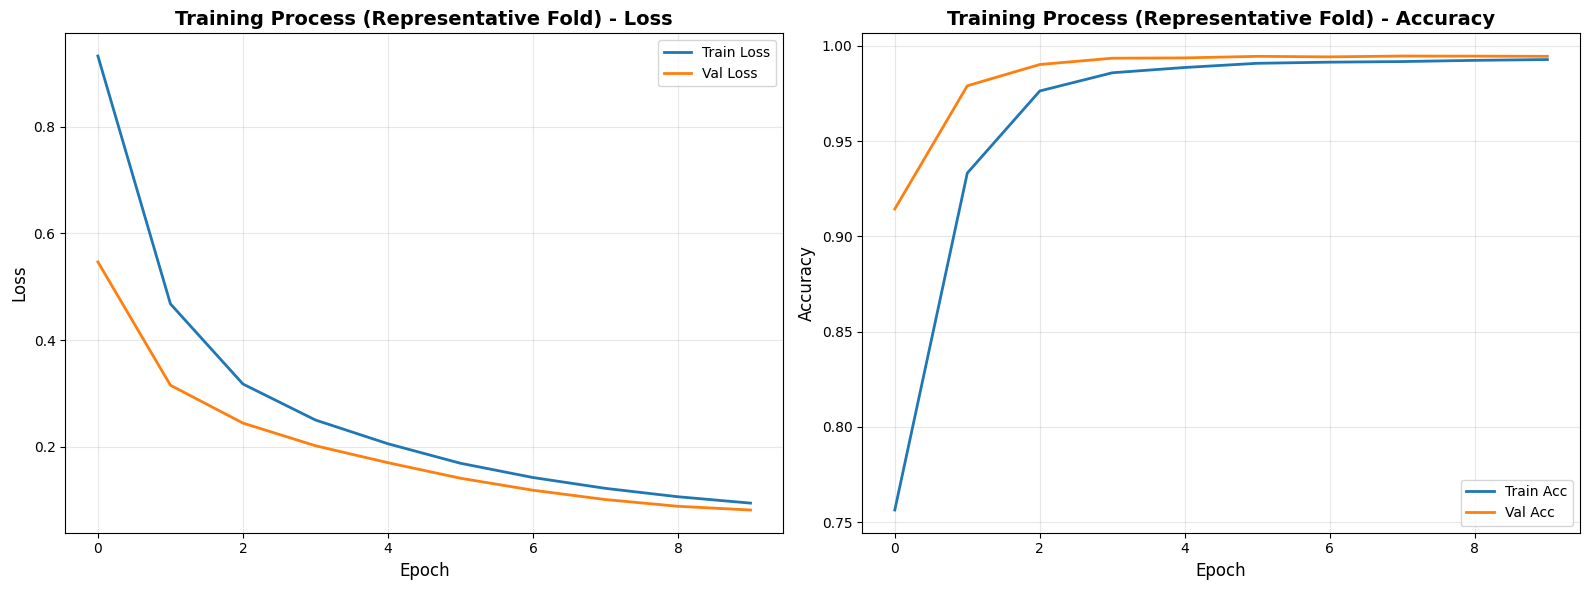


Classification Report:
              precision    recall  f1-score   support

    ENHANCER     1.0000    0.9843    0.9921      5419
    PROMOTER     0.9945    1.0000    0.9972      5420
  INTERGENIC     0.9900    1.0000    0.9950      5420

    accuracy                         0.9948     16259
   macro avg     0.9948    0.9948    0.9948     16259
weighted avg     0.9948    0.9948    0.9948     16259



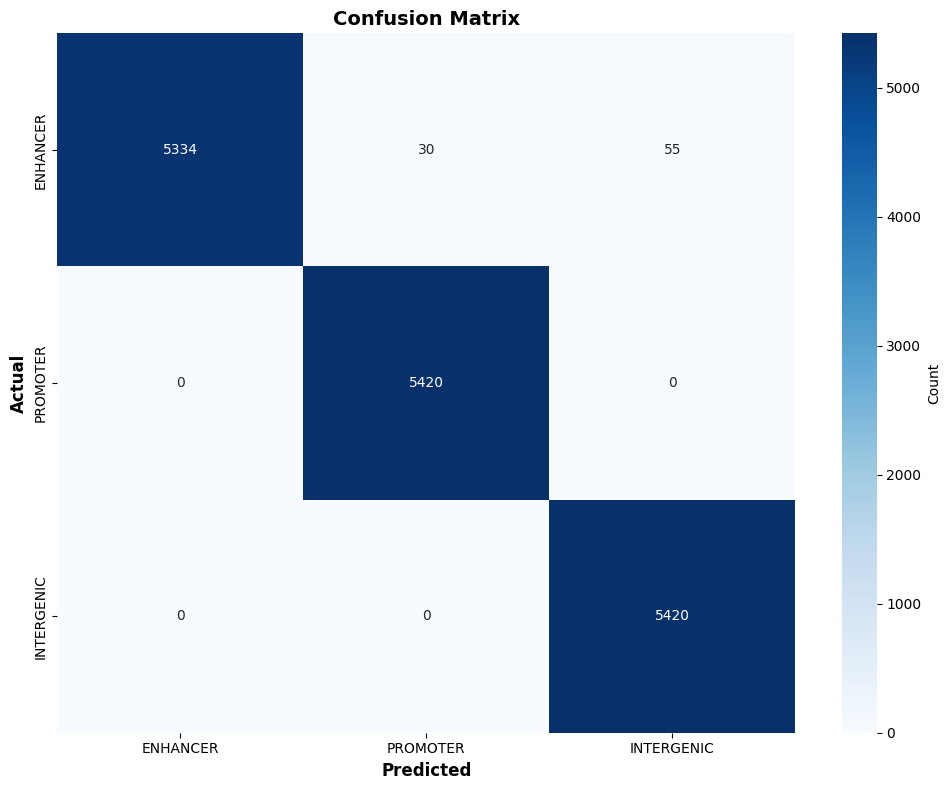

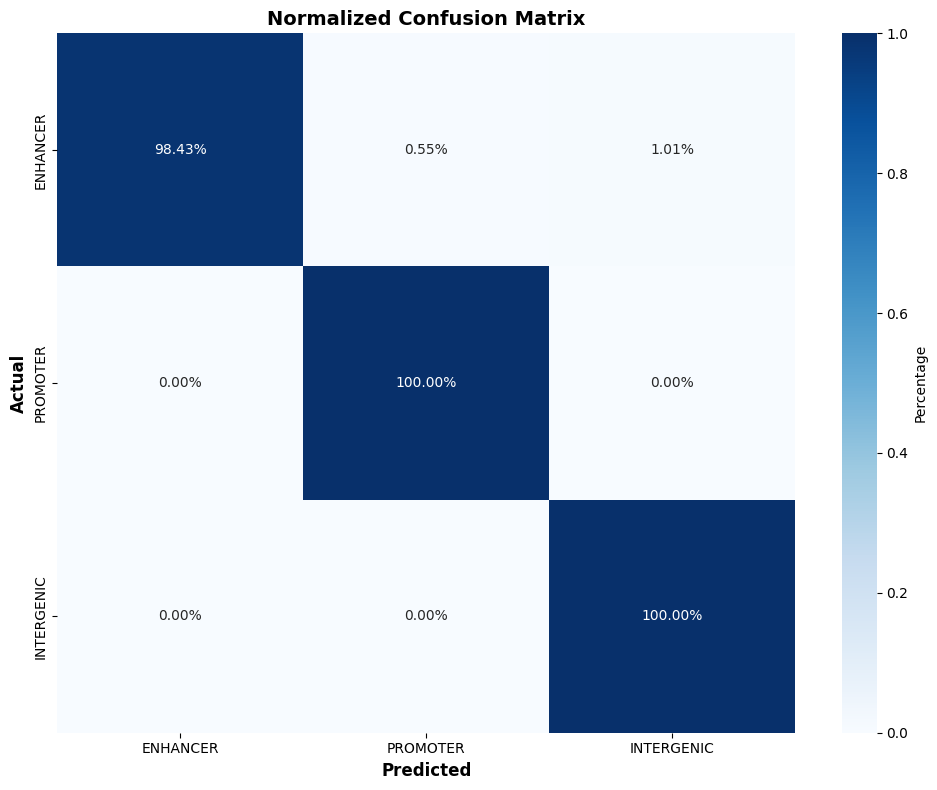


Per-Class Accuracy Analysis:
  ENHANCER: 98.43% (5419 samples)
  PROMOTER: 100.00% (5420 samples)
  INTERGENIC: 100.00% (5420 samples)

Sample Predictions (Random Sample):
  ✓ True: INTERGENIC   | Predicted: INTERGENIC   | Confidence: 99.95%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 100.00%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.93%
  ✓ True: INTERGENIC   | Predicted: INTERGENIC   | Confidence: 99.76%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.90%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 100.00%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 100.00%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 100.00%
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 100.00%
  ✓ True: INTERGENIC   | Predicted: INTERGENIC   | Confidence: 99.93%


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print(f"--- Final Evaluation using the BEST Model found in CV ---")

# 1. Evaluate on test set using the BEST model found during CV
test_results = best_model.evaluate(X_test_ohe, y_test_cat, verbose=0)

# Create a dictionary of metrics
test_metrics = dict(zip(best_model.metrics_names, test_results))

# הדפסת עזר כדי לראות אילו מפתחות באמת קיימים (למקרה של דיבאג עתידי)
print(f"Available metrics keys: {list(test_metrics.keys())}")

print(f"\nTest Results:")
print(f"  Loss:      {test_metrics['loss']:.4f}")

# --- תיקון לשליפת ה-Accuracy ---
# חיפוש דינמי של המפתח הנכון (accuracy / acc / categorical_accuracy)
acc_key = next((k for k in test_metrics.keys() if 'acc' in k), None)

if acc_key:
    print(f"  Accuracy:  {test_metrics[acc_key]:.4f}")
else:
    print("  Accuracy:  N/A (Could not find accuracy metric)")

if 'auc' in test_metrics:
    print(f"  AUC:       {test_metrics['auc']:.4f}")

# 2. Make predictions
print("\nGenerating predictions...")
predictions = best_model.predict(X_test_ohe, verbose=0)
predicted_classes = predictions.argmax(axis=1)
y_test_classes = y_test_cat.argmax(axis=1)

# 3. Plot training history (Of the LAST Fold)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# בדיקה שההיסטוריה קיימת לפני הציור
if 'loss' in history.history:
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Process (Representative Fold) - Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Accuracy - חיפוש המפתח הנכון בהיסטוריה גם כן
    hist_acc_key = next((k for k in history.history.keys() if 'acc' in k and 'val' not in k), None)
    hist_val_acc_key = next((k for k in history.history.keys() if 'val_' in k and 'acc' in k), None)
    
    if hist_acc_key and hist_val_acc_key:
        axes[1].plot(history.history[hist_acc_key], label='Train Acc', linewidth=2)
        axes[1].plot(history.history[hist_val_acc_key], label='Val Acc', linewidth=2)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('Accuracy', fontsize=12)
        axes[1].set_title('Training Process (Representative Fold) - Accuracy', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)
else:
    print("Warning: No training history available to plot.")

plt.tight_layout()
plt.show()

# 4. Classification Report
class_names = ['ENHANCER', 'PROMOTER', 'INTERGENIC']

print("\nClassification Report:")
print(classification_report(
    y_test_classes, 
    predicted_classes,
    target_names=class_names,
    digits=4
))

# 5. Confusion Matrix
cm = confusion_matrix(y_test_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.2%', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Percentage'}
)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Per-class performance analysis
print("\nPer-Class Accuracy Analysis:")
for i, class_name in enumerate(class_names):
    class_mask = (y_test_classes == i)
    if class_mask.sum() > 0:
        class_acc = (predicted_classes[class_mask] == i).sum() / class_mask.sum()
        print(f"  {class_name}: {class_acc:.2%} ({class_mask.sum()} samples)")
    else:
        print(f"  {class_name}: No samples in test set")

# 8. Show some example predictions
print("\nSample Predictions (Random Sample):")
random_indices = np.random.choice(len(predicted_classes), 10, replace=False)
for i in random_indices:
    true_class = class_names[y_test_classes[i]]
    pred_class = class_names[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]]
    match = "✓" if y_test_classes[i] == predicted_classes[i] else "✗"
    print(f"  {match} True: {true_class:12s} | Predicted: {pred_class:12s} | Confidence: {confidence:.2%}")


--- Final Comparison: SVM vs. CNN (Held-out Test Set) ---
Training SVM on full training data...


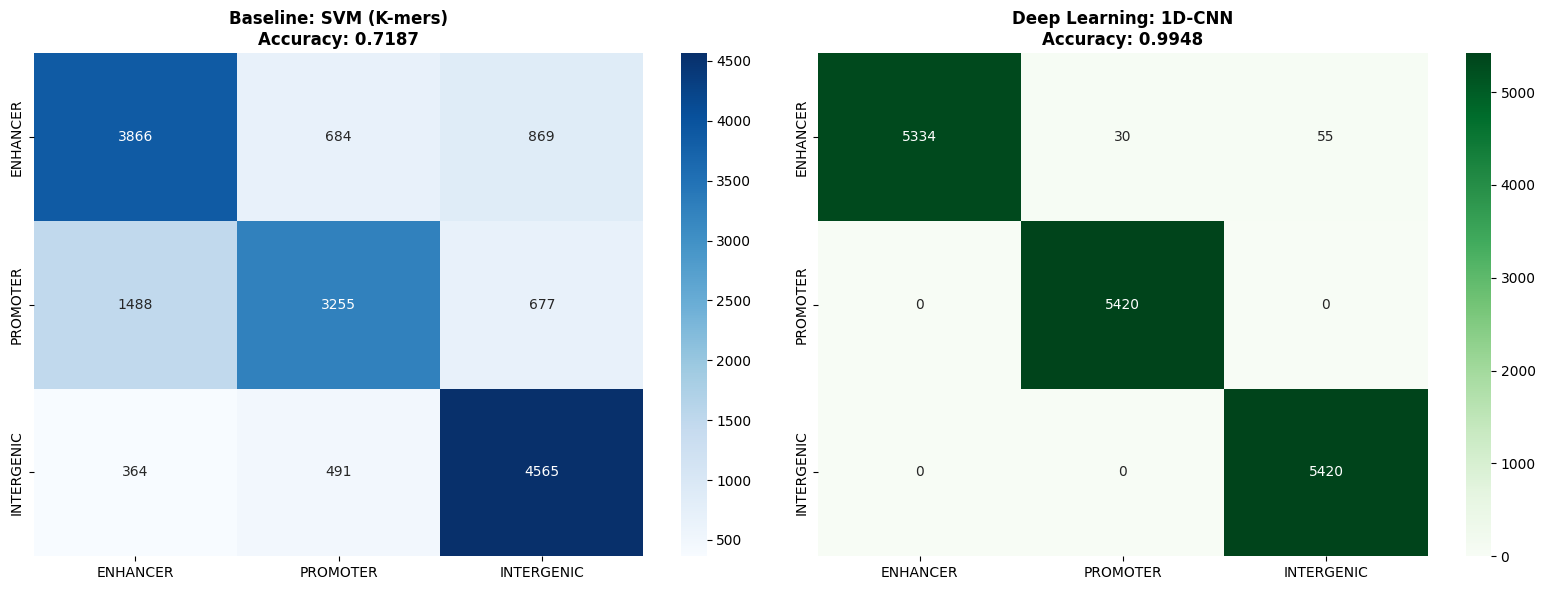


Final Result Summary:
SVM Accuracy: 71.87%
CNN Accuracy: 99.48%
Improvement:  +38.40%

--- Detailed Report (CNN) ---
              precision    recall  f1-score   support

    ENHANCER     1.0000    0.9843    0.9921      5419
    PROMOTER     0.9945    1.0000    0.9972      5420
  INTERGENIC     0.9900    1.0000    0.9950      5420

    accuracy                         0.9948     16259
   macro avg     0.9948    0.9948    0.9948     16259
weighted avg     0.9948    0.9948    0.9948     16259



In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Final Comparison: SVM vs. CNN (Held-out Test Set) ---")

# 1. הכנת הנתונים ל-SVM (שימוש ב-K-mers כפי שהוגדר במקור)
# אנו משתמשים ב-X_train ו-X_test הגולמיים (רצפי אותיות) שהוגדרו בהתחלה
# הערה: עלינו לאמן את ה-SVM מחדש על כל ה-Train+Val כדי שיהיה הוגן מול ה-CNN
print("Training SVM on full training data...")
X_train_full_raw = X_train + X_val  # איחוד רשימות
y_train_full = np.concatenate([y_train, y_val])

# וקטוריזציה (K-mers) - בהנחה ששמרת את הפרמטרים הטובים מה-Optuna
# אם לא, נשתמש בברירת מחדל סבירה (למשל K=4 או 5)
k_mer_size = 5 # או המספר שמצאת ב-Optuna
vectorizer = CountVectorizer(analyzer='char', ngram_range=(k_mer_size, k_mer_size))
X_train_vec = vectorizer.fit_transform(X_train_full_raw)
X_test_vec = vectorizer.transform(X_test) # המרת ה-Test Set

# אימון SVM
svm_model = LinearSVC(C=1.0, max_iter=2000, dual="auto") # C=1.0 או הערך מ-Optuna
svm_model.fit(X_train_vec, y_train_full)

# חיזוי SVM
y_pred_svm = svm_model.predict(X_test_vec)
acc_svm = accuracy_score(y_test, y_pred_svm)

# 2. קבלת התחזיות מה-CNN (המודל הטוב ביותר מה-CV)
# X_test_ohe הוכן בתאים הקודמים
y_pred_cnn_probs = best_model.predict(X_test_ohe, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)

# 3. ויזואליזציה - מטריצות בלבול
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['ENHANCER', 'PROMOTER', 'INTERGENIC']

# SVM Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'Baseline: SVM (K-mers)\nAccuracy: {acc_svm:.4f}', fontsize=12, fontweight='bold')

# CNN Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f'Deep Learning: 1D-CNN\nAccuracy: {acc_cnn:.4f}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. סיכום טקסטואלי
print(f"\nFinal Result Summary:")
print(f"SVM Accuracy: {acc_svm:.2%}")
print(f"CNN Accuracy: {acc_cnn:.2%}")
improvement = (acc_cnn - acc_svm) / acc_svm * 100
print(f"Improvement:  {improvement:+.2f}%")

print("\n--- Detailed Report (CNN) ---")
print(classification_report(y_test, y_pred_cnn, target_names=labels, digits=4))


--- Model Interpretability Analysis ---
Visualizing weights from layer: conv1d_12


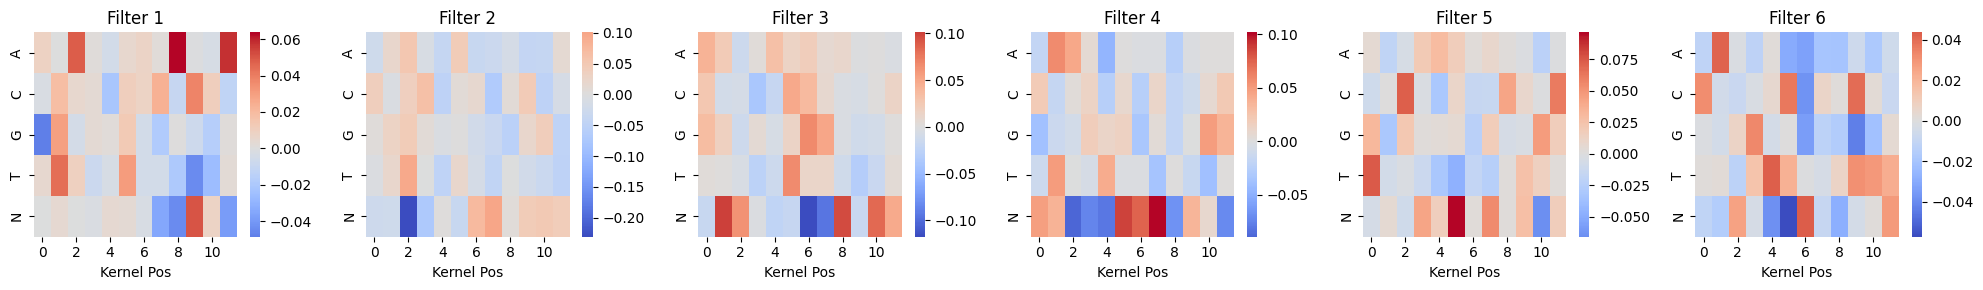

Generating Saliency Map for sample 10 (Class: ENHANCER)...


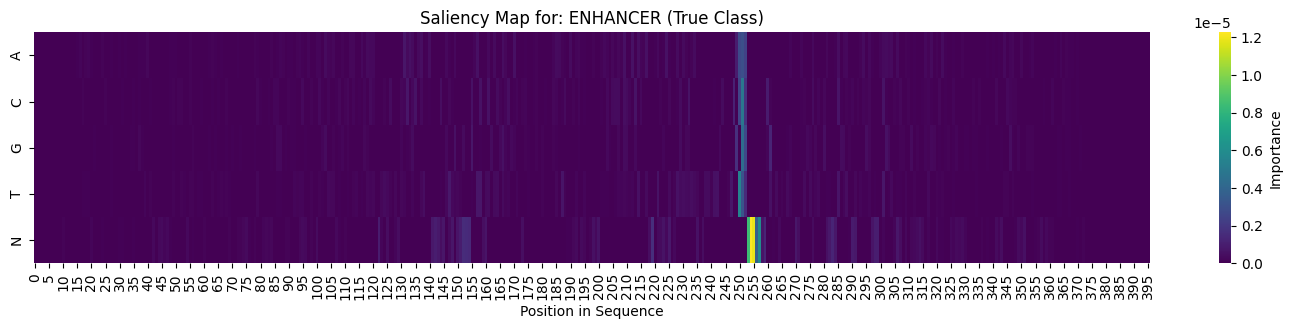

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_saliency_map(model, seq_ohe, true_label_idx, id2label_map):
    """
    מייצר מפת חום המראה אילו נוקלאוטידים השפיעו הכי הרבה על ההחלטה
    """
    # המרת הרצף ל-Tensor (Batch size = 1)
    input_tensor = tf.convert_to_tensor([seq_ohe], dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        preds = model(input_tensor)
        # אנו מתמקדים בציון שנתן המודל למחלקה האמיתית
        loss = preds[0][true_label_idx]
        
    # חישוב הנגזרת (Gradients) של הציון ביחס לקלט
    grads = tape.gradient(loss, input_tensor)[0].numpy()
    
    # נרמול להצגה (לוקחים רק תרומה חיובית - ReLU) - מה ש"הדליק" את הנוירון
    grads = np.maximum(grads, 0)
    
    # ויזואליזציה
    plt.figure(figsize=(18, 3))
    # Transpose כדי שהבסיסים (ACGTN) יהיו בציר ה-Y
    sns.heatmap(grads.T, cmap="viridis", yticklabels=['A','C','G','T','N'], cbar_kws={'label': 'Importance'})
    plt.title(f"Saliency Map for: {id2label_map[true_label_idx]} (True Class)")
    plt.xlabel("Position in Sequence")
    plt.show()

def visualize_first_layer_filters(model):
    """
    מציג את המשקולות של הפילטרים בשכבה הראשונה.
    פילטרים אלו לרוב מייצגים מוטיבים ביולוגיים.
    """
    # מציאת השכבה הקונבולוציונית הראשונה
    conv_layers = [layer for layer in model.layers if 'conv1d' in layer.name]
    if not conv_layers:
        print("No Conv1D layers found.")
        return
    
    first_conv = conv_layers[0]
    weights = first_conv.get_weights()[0] # Shape: (kernel_size, input_channels, filters)
    
    # בחירת מספר פילטרים להצגה
    n_filters_to_show = min(6, weights.shape[2])
    fig, axes = plt.subplots(1, n_filters_to_show, figsize=(20, 3))
    
    print(f"Visualizing weights from layer: {first_conv.name}")
    for i in range(n_filters_to_show):
        # שליפת הפילטר ה-i
        w = weights[:, :, i] 
        sns.heatmap(w.T, ax=axes[i], cmap="coolwarm", center=0, yticklabels=['A','C','G','T','N'])
        axes[i].set_title(f"Filter {i+1}")
        axes[i].set_xlabel("Kernel Pos")
    
    plt.tight_layout()
    plt.show()

# --- הרצת ניתוח הפרשנות ---
print("\n--- Model Interpretability Analysis ---")

# 1. הצגת פילטרים (מה המודל מחפש בגדול?)
visualize_first_layer_filters(best_model)

# 2. מפת חום לרצף ספציפי (למה הוא סיווג דוגמה ספציפית כ-Promoter?)
# לוקחים דוגמה אקראית מסט הולידציה האחרון
sample_idx = 10  # אתה יכול לשנות אינדקס זה כדי לראות רצפים אחרים
sample_seq = X_test_ohe[sample_idx] 
sample_label = y_test[sample_idx]

print(f"Generating Saliency Map for sample {sample_idx} (Class: {ID2LABEL[sample_label]})...")
plot_saliency_map(best_model, sample_seq, sample_label, ID2LABEL)

In [ ]:
# model.save('dna_cnn_model.keras')